# Fitting example
This is based on Example 6.6 in Seborg. We fit a number of different models to data. The data has been read off the figure in the textbook, so the coefficients may differ slightly from what is reported there.

In [89]:
import pandas
import matplotlib.pyplot as plt
import numpy
import scipy
%matplotlib inline

In [69]:
df = pandas.read_csv('fitting.csv', index_col=0)

In [71]:
x = df.index
y = df.y

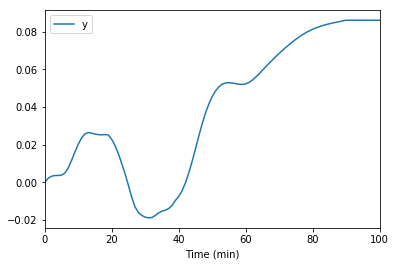

In [70]:
df.plot()

## 1 Step response model with 50 coefficients
Since the data is already a step response with $\Delta t=1$ minute we can simply take every second data point as the step response model with $\Delta t=2$ min.

In [74]:
S = y[::2]

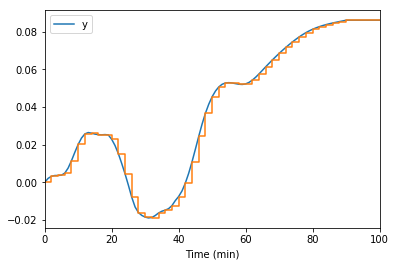

In [87]:
df.plot()
S.plot(drawstyle='steps-post')

## 2 Discrete-time ARX model

$$y(k) = a_1 y(k - 1) + a_2 y(k - 2) + a_3 y(k - 3) + a_4 y(k - 4) + b_1 u(k - 1) + b_2 u(k - 2) + b_3 u(k - 3)$$

In [194]:
N = 99

In [195]:
Y = numpy.atleast_2d(y.loc[1:N]).T

Coefficients of $a$

In [196]:
X1 = scipy.linalg.toeplitz(y.loc[:N-1], [0, 0, 0, 0])

coefficients of $b$

In [207]:
X2 = scipy.linalg.toeplitz(numpy.ones(N), [1, 0, 0, 0])

In [208]:
X = numpy.hstack([X1, X2])

In [221]:
beta = numpy.linalg.lstsq(X, Y)[0]
beta

array([[  2.89434776e+00],
       [ -3.08506475e+00],
       [  1.43803020e+00],
       [ -2.48751576e-01],
       [  2.11848135e-03],
       [ -5.01557962e-03],
       [  3.72508555e-03],
       [ -7.31792875e-04]])

Predict with this model for the whole time frame

In [222]:
def u(k):
    if k < 1:
        return 0
    else:
        return 1

In [223]:
# beta = [3.317, -4.033, 2.108, 0.392, 
#         -0.00922, 0.0322, -0.037, 0.0141]

In [224]:
a1, a2, a3, a4, b1, b2, b3, b4 = beta

In [225]:
yk_1 = yk_2 = yk_3 = yk_4 = 0

In [230]:
ypred = [0]
for k in range(1, 100):
    yk = a1*yk_1 + a2*yk_2 + a3*yk_3 + a4*yk_4 + b1*u(k - 1) + b2*u(k - 2) + b3*u(k - 3) + b4*u(k - 4)
    ypred.append(yk)
    yk_1, yk_2, yk_3, yk_4 = yk, yk_1, yk_2, yk_3

In [231]:
ypred[0]

0

In [232]:
b3

array([ 0.00372509])

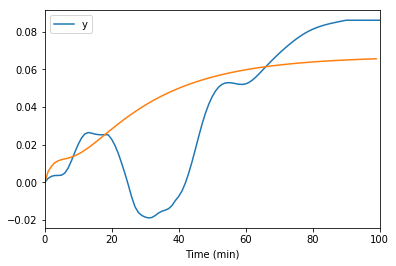

In [233]:
df.plot()
plt.plot(ypred)

## 3 First order plus time delay model

$$G(s) = \frac{Ke^{-\theta s}}{\tau s + 1}$$

## 4 Second-order-plus-time-delay model with inverse response

$$G(s) = \frac{K(1 - \tau_a s)e^{-\theta s}}{(\tau_1 s + 1)(\tau_2 s + 1)}$$